# *Baseline shortlist*: evidencia final de la campaña confirmatoria del Experimento 1

Notebook único de evidencia para el carril *baseline*/*shortlist* (Experimento 1). Convierte los `budgeted_search_summary.json` de la campaña `20260502T120458Z` en tablas auditables, gráficas comparativas y artefactos exportables.

Este notebook no entrena modelos. Lee artefactos persistidos, comprueba contadores exploratorio/confirmatorio al cargar y genera evidencia en `reports/validation/experiments/baseline_shortlist_20260502T120458Z_evidence/`.

**Métrica primaria:** Sharpe agregado *out-of-sample* (`aggregate_strategy_sharpe`) del candidato confirmatorio. **DSR Exp1 (N=22 por celda):** columna diagnóstica `diagnostic_study_close_dsr` en la tabla ejecutiva, sin reglas de aceptación. **DSR carril completo (Exp1 + Exp2 + carril 2.5):** diagnóstico embebido en `05_resumen_greedy_contextual.ipynb` (sección 7) y `06_resumen_carril_riesgo_greedy_contextual.ipynb` (sección 8), recalculado desde retornos OOS con N total por celda y persistido en `reports/validation/dsr_exact/dsr_exact_post_experiment_supervised.csv`.

**Alcance:** 15 celdas (`5` símbolos × `3` métodos), `20` trials exploratorios + `2` confirmatorios por celda (`22` en total).

**Complemento:** `05_modelado_predictivo/02_evidencia_robustez_fold_shortlist_baseline.ipynb` (robustez fold-level del campeón, contraste entre definiciones de selección y solape de etiquetas entre métodos) exporta al mismo directorio `baseline_shortlist_20260502T120458Z_evidence/`.


In [1]:
from __future__ import annotations

import json
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)
plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def locate_repo_root(start: Path | None = None) -> Path:
    root = (start or Path.cwd()).resolve()
    while root != root.parent and not (root / "src").is_dir():
        root = root.parent
    if not (root / "src").is_dir():
        raise FileNotFoundError("No se encontró la raíz del repositorio desde el directorio actual.")
    return root


ROOT = locate_repo_root()
CAMPAIGN_SUFFIX = "20260502T120458Z"
EXPECTED_SYMBOLS = ("BTCUSDT", "ETHUSDT", "BNBUSDT", "XRPUSDT", "SOLUSDT")
EXPECTED_METHODS = ("triple_barrier", "trend_scanning", "fixed_horizon")
REPORT_ROOT = ROOT / "reports" / "validation" / "experiments"
EVIDENCE_DIR = REPORT_ROOT / f"baseline_shortlist_{CAMPAIGN_SUFFIX}_evidence"
TABLE_DIR = EVIDENCE_DIR / "tables"
FIGURE_DIR = EVIDENCE_DIR / "figures"
for directory in (TABLE_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(f"ROOT={ROOT}")
print(f"EVIDENCE_DIR={EVIDENCE_DIR}")

COLUMNAS_ES = {
    "symbol": "simbolo",
    "method": "metodo",
    "family": "familia",
    "phase": "fase",
    "study_id": "id_estudio",
    "trial_id": "id_trial",
    "rank": "rango",
    "global_rank": "rango_global",
    "promotion_rank": "rango_promocion",
    "trial_status": "estado_trial",
    "cell_status": "estado_celda",
    "n_cells": "n_celdas",
    "cells": "n_celdas",
    "summary_present": "resumen_presente",
    "summary_path": "ruta_resumen",
    "summary_mtime_utc": "mtime_resumen_utc",
    "mtime_utc": "mtime_utc",
    "size_bytes": "tamano_bytes",
    "sha256": "sha256",
    "csv": "ruta_csv",
    "html": "ruta_html",
    "figure": "figura",
    "rows": "n_filas",
    "description": "descripcion",
    "n_completed": "n_completados",
    "n_pruned": "n_podados",
    "n_failed": "n_fallidos",
    "n_total": "n_total",
    "total_trials": "trials_total",
    "confirmatory_n_completed": "n_completados_conf",
    "confirmatory_n_failed": "n_fallidos_conf",
    "n_confirmatory_candidates": "n_candidatos_conf",
    "exploratory_budget": "presupuesto_exp",
    "confirmatory_budget": "presupuesto_conf",
    "expected_exploratory_trials": "trials_exp_esperados",
    "expected_confirmatory_trials": "trials_conf_esperados",
    "exploratory_ok": "exp_ok",
    "confirmatory_ok": "conf_ok",
    "outer_dsr": "dsr_outer",
    "study_close_dsr": "dsr_cierre_estudio",
    "best_outer_dsr": "mejor_dsr_outer",
    "best_study_close_dsr": "mejor_dsr_cierre_exp",
    "best_trial_id": "id_mejor_trial",
    "best_confirmatory_trial_id": "id_mejor_trial_conf",
    "best_confirmatory_outer_dsr": "mejor_dsr_outer_conf",
    "best_confirmatory_study_close_dsr": "mejor_dsr_cierre_conf",
    "best_confirmatory_trial_id_resolved": "id_mejor_trial_conf_resuelto",
    "best_confirmatory_family": "familia_mejor_conf",
    "best_confirmatory_fracdiff_policy": "fracdiff_mejor_conf",
    "resolved_confirmatory_dsr": "dsr_conf_resuelto",
    "diagnostic_study_close_dsr": "dsr_cierre_diagnostico",
    "confirmatory_strategy_sharpe": "sharpe_estrategia_conf",
    "confirmatory_strategy_sortino": "sortino_estrategia_conf",
    "confirmatory_minus_exploratory_dsr": "dsr_conf_menos_exp",
    "fracdiff_policy": "politica_fracdiff",
    "aggregate_strategy_sharpe": "sharpe_estrategia_agreg",
    "aggregate_strategy_sortino": "sortino_estrategia_agreg",
    "optimizer_scalar_value": "valor_escalar_opt",
    "optimizer_scalar_kind": "tipo_escalar_opt",
    "exploratory_source_optuna_trial_number": "n_trial_optuna_fuente",
    "optuna_trial_number": "n_trial_optuna",
    "is_confirmatory_candidate": "es_candidato_conf",
    "n_wins": "n_victorias",
    "n_trials": "n_trials",
    "n_symbols": "n_simbolos",
    "n_methods": "n_metodos",
    "median_dsr": "mediana_dsr",
    "max_dsr": "max_dsr",
    "top1_count": "n_top1",
    "positive_dsr_rate": "tasa_dsr_positivo",
    "median_oos_sharpe": "mediana_sharpe_oos",
    "max_oos_sharpe": "max_sharpe_oos",
    "positive_sharpe_rate": "tasa_sharpe_positivo",
    "mean_confirmatory_dsr": "media_dsr_conf",
    "median_confirmatory_dsr": "mediana_dsr_conf",
    "max_confirmatory_dsr": "max_dsr_conf",
    "min_confirmatory_dsr": "min_dsr_conf",
    "best_study_close_dsr_local": "mejor_dsr_cierre_local",
    "best_confirmatory_study_close_dsr_local": "mejor_dsr_cierre_conf_local",
    "study_close_dsr_local": "dsr_cierre_local",
    "study_close_dsr_global": "dsr_cierre_celda",
    "study_close_dsr_primary_per_cell": "dsr_cierre_celda",
    "study_close_dsr_campaign_global": "dsr_cierre_campana",
    "dsr_global_deflation_n_exploratory": "n_deflacion_exp",
    "dsr_global_deflation_n_confirmatory": "n_deflacion_conf",
    "dsr_global_expected_max_sharpe_exploratory": "e_max_sr_exp",
    "dsr_global_expected_max_sharpe_confirmatory": "e_max_sr_conf",
    "e_max_local_phase": "e_max_sr_fase_local",
    "e_max_primary_per_cell": "e_max_sr_celda",
    "e_max_campaign_global": "e_max_sr_campana",
    "n_primary_per_cell": "n_primario_celda",
    "sr_std_primary_per_cell": "sr_std_celda",
    "expected_max_sharpe_primary_per_cell": "e_max_sr_primario_celda",
    "best_study_close_dsr_global": "mejor_dsr_cierre_celda",
    "best_confirmatory_study_close_dsr_global": "mejor_dsr_cierre_conf_celda",
    "best_confirmatory_study_close_dsr_campaign_global": "mejor_dsr_cierre_conf_campana",
    "dsr_campaign_global_n": "n_deflacion_campana",
    "dsr_campaign_global_sr_std": "sr_std_campana",
    "dsr_campaign_global_expected_max_sharpe": "e_max_sr_campana",
    "n_campaign_global": "n_campana_global",
    "sr_std_campaign_global": "sr_std_campana_global",
    "expected_max_sharpe_campaign_global": "e_max_sr_campana_global",
    "n_completed_exploratory": "n_completados_exp",
    "n_completed_confirmatory": "n_completados_conf",
    "config_hash": "hash_config",
    "error_message": "mensaje_error",
    "risk_policy_name": "politica_riesgo",
    "sizing_policy_name": "politica_sizing",
    "artifact_regenerated_at_utc": "artefacto_regenerado_utc",
    "artifact_contract_version": "version_contrato_artefacto",
}

# Traducciones parciales de claves de config frecuentes
CONFIG_CLAVES_ES = {
    "family": "familia",
    "fracdiff_policy": "fracdiff",
    "risk_policy_name": "riesgo",
    "sizing_policy_name": "sizing",
    "sequence_lookback_bars": "lookback",
    "lstm_max_epochs": "epochs_lstm",
    "lstm_batch_size": "batch_lstm",
    "lstm_learning_rate": "lr_lstm",
    "voting_xgb_weight": "peso_xgb_voting",
}


def _nombre_columna_es(nombre: str) -> str:
    if nombre in COLUMNAS_ES:
        return COLUMNAS_ES[nombre]
    if nombre.startswith("config_"):
        clave = nombre.removeprefix("config_")
        sufijo = CONFIG_CLAVES_ES.get(clave, clave)
        return f"cfg_{sufijo}"
    return nombre


def display_es(frame: pd.DataFrame | pd.Series) -> None:
    """Renderiza un DataFrame o Series con cabeceras en español (snake_case)."""
    if isinstance(frame, pd.Series):
        frame = frame.to_frame(name=frame.name)
    vista = frame.copy()
    vista.columns = [_nombre_columna_es(str(col)) for col in vista.columns]
    if vista.index.name:
        vista.index.name = _nombre_columna_es(str(vista.index.name))
    display(vista)


GLOBAL_DSR_ARTIFACT_DIR = EVIDENCE_DIR
GLOBAL_DSR_ROWS_CSV = TABLE_DIR / "baseline_shortlist_global_dsr_rows.csv"
GLOBAL_DSR_STUDIES_CSV = TABLE_DIR / "baseline_shortlist_global_dsr_studies.csv"
GLOBAL_DSR_MANIFEST_JSON = GLOBAL_DSR_ARTIFACT_DIR / "baseline_shortlist_global_dsr_manifest.json"


def apply_global_dsr_from_artifact(
    studies: pd.DataFrame,
    exploratory: pd.DataFrame,
    confirmatory: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, dict[str, float]]:
    """Carga la deflación de DSR persistida por el script CLI."""
    if not GLOBAL_DSR_MANIFEST_JSON.is_file():
        raise FileNotFoundError(
            "No se encuentra el artefacto de deflación global de DSR. "
            "Ejecuta: python scripts/recompute_global_dsr_baseline_shortlist.py "
            f"--campaign-stamp {CAMPAIGN_SUFFIX}"
        )
    rows_df = pd.read_csv(GLOBAL_DSR_ROWS_CSV)
    studies_df = pd.read_csv(GLOBAL_DSR_STUDIES_CSV)
    manifest = json.loads(GLOBAL_DSR_MANIFEST_JSON.read_text(encoding="utf-8"))

    studies = studies.copy()
    exploratory = exploratory.copy()
    confirmatory = confirmatory.copy()

    def _merge_phase(frame: pd.DataFrame, phase: str) -> pd.DataFrame:
        if frame.empty:
            return frame
        subset = rows_df[rows_df["phase"] == phase][
            [
                "study_id",
                "trial_id",
                "study_close_dsr_local",
                "study_close_dsr_global",
                "study_close_dsr_campaign_global",
            ]
        ]
        merged = frame.merge(subset, on=["study_id", "trial_id"], how="left")
        if "study_close_dsr_local" in merged.columns:
            merged["study_close_dsr_local"] = merged["study_close_dsr_local"].fillna(
                merged.get("study_close_dsr")
            )
        else:
            merged["study_close_dsr_local"] = merged.get("study_close_dsr")
        merged["study_close_dsr"] = merged["study_close_dsr_global"].combine_first(
            merged.get("study_close_dsr")
        )
        drop_cols = [c for c in ("study_close_dsr_global", "study_close_dsr_campaign_global") if c in merged.columns]
        return merged.drop(columns=drop_cols)

    exploratory = _merge_phase(exploratory, "exploratory")
    confirmatory = _merge_phase(confirmatory, "confirmatory")

    studies = studies.merge(
        studies_df[
            [
                "study_id",
                "best_study_close_dsr_local",
                "best_study_close_dsr_global",
                "best_confirmatory_study_close_dsr_local",
                "best_confirmatory_study_close_dsr_global",
                "best_confirmatory_study_close_dsr_campaign_global",
                "dsr_global_deflation_n_exploratory",
                "dsr_global_deflation_n_confirmatory",
                "dsr_global_expected_max_sharpe_exploratory",
                "dsr_global_expected_max_sharpe_confirmatory",
            ]
        ],
        on="study_id",
        how="left",
    )
    studies["best_study_close_dsr"] = studies["best_study_close_dsr_global"].combine_first(
        studies.get("best_study_close_dsr")
    )
    studies["best_confirmatory_study_close_dsr"] = studies[
        "best_confirmatory_study_close_dsr_global"
    ].combine_first(studies.get("best_confirmatory_study_close_dsr"))
    studies = studies.drop(
        columns=[
            "best_study_close_dsr_global",
            "best_confirmatory_study_close_dsr_global",
        ]
    )

    if "deflation_policy" in manifest:
        campaign = manifest["deflation_policy"]["campaign_global_sensitivity"]
        n_per_cell_typical = int(
            pd.to_numeric(studies_df.get("n_primary_per_cell"), errors="coerce")
            .dropna()
            .median()
        ) if "n_primary_per_cell" in studies_df.columns else 22
        e_max_per_cell_median = float(
            pd.to_numeric(
                studies_df.get("expected_max_sharpe_primary_per_cell"),
                errors="coerce",
            )
            .dropna()
            .median()
        ) if "expected_max_sharpe_primary_per_cell" in studies_df.columns else float("nan")
        summary = {
            "n_global_exploratory": n_per_cell_typical,
            "n_global_confirmatory": n_per_cell_typical,
            "sr_std_global_exploratory": float("nan"),
            "sr_std_global_confirmatory": float("nan"),
            "expected_max_sharpe_global_exploratory": e_max_per_cell_median,
            "expected_max_sharpe_global_confirmatory": e_max_per_cell_median,
            "n_campaign_global": campaign["n_campaign"],
            "sr_std_campaign_global": campaign["sr_std_campaign"],
            "expected_max_sharpe_campaign_global": campaign["expected_max_sharpe_campaign"],
            "artifact_regenerated_at_utc": manifest.get("regenerated_at_utc"),
            "artifact_contract_version": manifest.get("contract_version"),
        }
    else:
        legacy = manifest["global_deflation"]
        summary = {
            "n_global_exploratory": legacy["n_exploratory"],
            "n_global_confirmatory": legacy["n_confirmatory"],
            "sr_std_global_exploratory": legacy["sr_std_exploratory"],
            "sr_std_global_confirmatory": legacy["sr_std_confirmatory"],
            "expected_max_sharpe_global_exploratory": legacy["expected_max_sharpe_exploratory"],
            "expected_max_sharpe_global_confirmatory": legacy["expected_max_sharpe_confirmatory"],
            "artifact_regenerated_at_utc": manifest.get("regenerated_at_utc"),
        }
    return studies, exploratory, confirmatory, summary


ROOT=/app
EVIDENCE_DIR=/app/reports/validation/experiments/baseline_shortlist_20260502T120458Z_evidence


## 1. Carga reproducible de *summaries*

La campaña se identifica por el sufijo `20260502T120458Z` (Experimento 1 definitivo, modo *confirmatory* estricto). Cada celda esperada sigue el patrón `baseline_shortlist_<symbol>_<method>_<suffix>/budgeted_search_summary.json`.

El bloque siguiente normaliza tres niveles de evidencia:

- Resumen por estudio: contadores, mejor *trial* confirmatorio y estado del *summary*.
- *Ranking* exploratorio: todas las filas `ranking_rows` de cada estudio.
- *Ranking* confirmatorio: las filas `confirmatory_ranking_rows`, que son las candidatas promovidas.

Cada celda `(símbolo, método de etiquetado)` corresponde a un universo de búsqueda Optuna con **22 intentos** (20 exploratorios + 2 confirmatorios) compartidos entre las arquitecturas que compiten en la celda. El criterio de cierre del paso es el **Sharpe agregado** *out-of-sample* del campeón confirmatorio.

Adicionalmente se carga el artefacto persistido de DSR por celda generado externamente con el *script*:

```
python scripts/recompute_global_dsr_baseline_shortlist.py --campaign-stamp 20260502T120458Z
```

Ese DSR queda incorporado como columna **diagnóstica** (`diagnostic_study_close_dsr`) sin reglas de aceptación asociadas en este notebook. La deflación coherente para el carril completo (Exp1 + Exp2 + carril 2.5) se reporta como **diagnóstico embebido** en `05_resumen_greedy_contextual.ipynb` (sección 7) y `06_resumen_carril_riesgo_greedy_contextual.ipynb` (sección 8), recalculada desde los retornos OOS reales con el N total acumulado por celda `(simbolo, metodo)` y persistida en `reports/validation/dsr_exact/dsr_exact_post_experiment_supervised.csv`.

In [2]:
def parse_study_folder(folder_name: str) -> tuple[str, str]:
    body = folder_name.replace("baseline_shortlist_", "").replace(f"_{CAMPAIGN_SUFFIX}", "")
    for method in EXPECTED_METHODS:
        if body.endswith(method):
            symbol = body[: -len(method) - 1].upper()
            return symbol, method
    raise ValueError(f"No se pudo inferir symbol/method desde {folder_name!r}")


def as_float(value: Any) -> float | np.nan:
    if value is None:
        return np.nan
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


def load_summary(path: Path) -> tuple[dict[str, Any], pd.DataFrame, pd.DataFrame]:
    payload = json.loads(path.read_text(encoding="utf-8"))
    search = payload.get("search_result") or {}
    symbol, method = parse_study_folder(path.parent.name)
    mtime_utc = datetime.fromtimestamp(path.stat().st_mtime, timezone.utc)

    summary = {
        "symbol": symbol,
        "method": method,
        "study_id": path.parent.name,
        "summary_path": str(path.relative_to(ROOT)),
        "summary_mtime_utc": mtime_utc.isoformat(),
        "exploratory_budget": search.get("exploratory_budget"),
        "confirmatory_budget": search.get("confirmatory_budget"),
        "n_completed": search.get("n_completed"),
        "n_failed": search.get("n_failed"),
        "n_pruned": search.get("n_pruned"),
        "n_total": search.get("n_total"),
        "confirmatory_n_completed": search.get("confirmatory_n_completed"),
        "confirmatory_n_failed": search.get("confirmatory_n_failed"),
        "n_confirmatory_candidates": search.get("n_confirmatory_candidates"),
        "best_trial_id": search.get("best_trial_id"),
        "best_study_close_dsr": as_float(search.get("best_study_close_dsr")),
        "best_confirmatory_trial_id": search.get("best_confirmatory_trial_id"),
        "best_confirmatory_study_close_dsr": as_float(search.get("best_confirmatory_study_close_dsr")),
        "best_confirmatory_outer_dsr": as_float(search.get("best_confirmatory_outer_dsr")),
    }

    ranking_rows = []
    for row in search.get("ranking_rows") or []:
        ranking_rows.append({
            "symbol": symbol,
            "method": method,
            "study_id": path.parent.name,
            "phase": "exploratory",
            **row,
        })

    confirmatory_rows = []
    for row in search.get("confirmatory_ranking_rows") or []:
        confirmatory_rows.append({
            "symbol": symbol,
            "method": method,
            "study_id": path.parent.name,
            "phase": "confirmatory",
            **row,
        })

    return summary, pd.DataFrame(ranking_rows), pd.DataFrame(confirmatory_rows)


summary_paths = sorted(REPORT_ROOT.glob(f"baseline_shortlist_*_{CAMPAIGN_SUFFIX}/budgeted_search_summary.json"))
summary_records: list[dict[str, Any]] = []
ranking_frames: list[pd.DataFrame] = []
confirmatory_frames: list[pd.DataFrame] = []

for path in summary_paths:
    summary, ranking_df, confirmatory_df = load_summary(path)
    summary_records.append(summary)
    ranking_frames.append(ranking_df)
    confirmatory_frames.append(confirmatory_df)

studies = pd.DataFrame(summary_records).sort_values(["symbol", "method"]).reset_index(drop=True)
ranking = pd.concat(ranking_frames, ignore_index=True) if ranking_frames else pd.DataFrame()
confirmatory = pd.concat(confirmatory_frames, ignore_index=True) if confirmatory_frames else pd.DataFrame()

studies, ranking, confirmatory, global_deflation_summary = apply_global_dsr_from_artifact(studies, ranking, confirmatory)

print(f"summaries={len(studies)} exploratory_rows={len(ranking)} confirmatory_rows={len(confirmatory)}")
print(
    f"DSR diagnóstico cargado -> N por celda={global_deflation_summary['n_global_confirmatory']} "
)
display_es(studies[["symbol", "method", "n_completed", "n_failed", "confirmatory_n_completed", "confirmatory_n_failed"]])

summaries=15 exploratory_rows=300 confirmatory_rows=30
DSR diagnóstico cargado -> N por celda=22 


,simbolo,metodo,n_completados,n_fallidos,n_completados_conf,n_fallidos_conf
0,BNBUSDT,fixed_horizon,20,0,2,0
1,BNBUSDT,trend_scanning,20,0,2,0
2,BNBUSDT,triple_barrier,20,0,2,0
3,BTCUSDT,fixed_horizon,20,0,2,0
4,BTCUSDT,trend_scanning,20,0,2,0
5,BTCUSDT,triple_barrier,20,0,2,0
6,ETHUSDT,fixed_horizon,20,0,2,0
7,ETHUSDT,trend_scanning,20,0,2,0
8,ETHUSDT,triple_barrier,20,0,2,0
9,SOLUSDT,fixed_horizon,20,0,2,0


## 2. Tablas ejecutivas de resultados

Dos lecturas complementarias, alineadas con **Sharpe agregado OOS** como KPI intermedio:

- **Tabla ejecutiva por celda (vista principal):** cobertura operativa + campeón confirmatorio elegido por **Sharpe** (no por DSR). Una sola columna DSR (`diagnostic_study_close_dsr`, N=22 por celda) como aviso estadístico, no como criterio de ranking.
- **Ranking global confirmatorio:** los dos candidatos promovidos por celda, ordenados por Sharpe descendente.

**Exportación:** `baseline_shortlist_executive_summary.csv` (vista slim, lista para memoria); `baseline_shortlist_executive_summary_audit.csv` (merge completo con metadatos DSR legacy del JSON, solo auditoría forense).

In [3]:
def flatten_config(config: Any) -> dict[str, Any]:
    if not isinstance(config, dict):
        return {}
    keys = [
        "family",
        "risk_policy_name",
        "sizing_policy_name",
        "fracdiff_policy",
        "max_depth",
        "learning_rate",
        "n_estimators",
        "subsample",
        "colsample_bytree",
        "min_child_weight",
        "reg_lambda",
        "sequence_lookback_bars",
        "lstm_max_epochs",
        "injection_strategy",
        "oof_inner_splits",
        "voting_xgb_weight",
    ]
    return {key: config.get(key) for key in keys if key in config}


for frame in (ranking, confirmatory):
    if not frame.empty:
        for col in ("outer_dsr", "study_close_dsr", "optimizer_scalar_value", "aggregate_strategy_sharpe", "aggregate_strategy_sortino"):
            if col in frame.columns:
                frame[col] = pd.to_numeric(frame[col], errors="coerce")

confirmatory_detail = confirmatory.copy()
if not confirmatory_detail.empty:
    config_cols = pd.DataFrame(
        [flatten_config(c) for c in confirmatory_detail.get("config", pd.Series(dtype=object))]
    ).add_prefix("config_")
    confirmatory_detail = pd.concat(
        [confirmatory_detail.drop(columns=["config"], errors="ignore"), config_cols],
        axis=1,
    )

best_confirmatory = (
    confirmatory_detail.sort_values(
        ["symbol", "method", "aggregate_strategy_sharpe"],
        ascending=[True, True, False],
    )
    .groupby(["symbol", "method"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)

_champion_by_sharpe = best_confirmatory[[
    "symbol",
    "method",
    "trial_id",
    "family",
    "fracdiff_policy",
    "aggregate_strategy_sharpe",
    "aggregate_strategy_sortino",
    "study_close_dsr",
    "exploratory_source_optuna_trial_number",
]].rename(columns={
    "trial_id": "best_confirmatory_trial_id_resolved",
    "family": "best_confirmatory_family",
    "fracdiff_policy": "best_confirmatory_fracdiff_policy",
    "aggregate_strategy_sharpe": "confirmatory_strategy_sharpe",
    "aggregate_strategy_sortino": "confirmatory_strategy_sortino",
    "study_close_dsr": "diagnostic_study_close_dsr",
})

executive_summary_audit = studies.merge(
    _champion_by_sharpe,
    on=["symbol", "method"],
    how="left",
)

EXECUTIVE_SUMMARY_VIEW_COLS = [
    "symbol",
    "method",
    "study_id",
    "n_completed",
    "n_failed",
    "confirmatory_n_completed",
    "confirmatory_n_failed",
    "best_confirmatory_trial_id_resolved",
    "best_confirmatory_family",
    "best_confirmatory_fracdiff_policy",
    "confirmatory_strategy_sharpe",
    "confirmatory_strategy_sortino",
    "diagnostic_study_close_dsr",
    "exploratory_source_optuna_trial_number",
]

executive_summary = (
    executive_summary_audit[
        [c for c in EXECUTIVE_SUMMARY_VIEW_COLS if c in executive_summary_audit.columns]
    ]
    .sort_values(["symbol", "method"])
    .reset_index(drop=True)
)

global_confirmatory_ranking = confirmatory_detail.sort_values(
    "aggregate_strategy_sharpe", ascending=False, na_position="last"
).reset_index(drop=True)
global_confirmatory_ranking.insert(0, "global_rank", np.arange(1, len(global_confirmatory_ranking) + 1))

CONFIRMATORY_RANKING_VIEW_COLS = [
    "global_rank",
    "symbol",
    "method",
    "trial_id",
    "family",
    "fracdiff_policy",
    "aggregate_strategy_sharpe",
    "aggregate_strategy_sortino",
    "study_close_dsr",
    "trial_status",
    "exploratory_source_optuna_trial_number",
]

print("Tabla ejecutiva por celda (Sharpe primario; DSR solo diagnóstico):")
display_es(executive_summary)
print("\nRanking global confirmatorio (ordenado por Sharpe agregado):")
display_es(
    global_confirmatory_ranking[
        [c for c in CONFIRMATORY_RANKING_VIEW_COLS if c in global_confirmatory_ranking.columns]
    ]
)

Tabla ejecutiva por celda (Sharpe primario; DSR solo diagnóstico):


,simbolo,metodo,id_estudio,n_completados,n_fallidos,n_completados_conf,n_fallidos_conf,id_mejor_trial_conf_resuelto,familia_mejor_conf,fracdiff_mejor_conf,sharpe_estrategia_conf,sortino_estrategia_conf,dsr_cierre_diagnostico,n_trial_optuna_fuente
0,BNBUSDT,fixed_horizon,baseline_shortlist_bnbusdt_fixed_horizon_20260502T120458Z,20,0,2,0,optuna-0000-d7924805,residual_hybrid,on,0.010434,0.014615,5.794372e-05,3
1,BNBUSDT,trend_scanning,baseline_shortlist_bnbusdt_trend_scanning_20260502T120458Z,20,0,2,0,optuna-0000-35f115b4,residual_hybrid,on,0.034979,0.057486,6.969418e-10,11
2,BNBUSDT,triple_barrier,baseline_shortlist_bnbusdt_triple_barrier_20260502T120458Z,20,0,2,0,optuna-0000-56e53c54,residual_hybrid,off,0.008768,0.015002,3.293843e-02,8
3,BTCUSDT,fixed_horizon,baseline_shortlist_btcusdt_fixed_horizon_20260502T120458Z,20,0,2,0,optuna-0000-44a5761f,residual_hybrid,on,0.010836,0.013532,2.190810e-04,8
4,BTCUSDT,trend_scanning,baseline_shortlist_btcusdt_trend_scanning_20260502T120458Z,20,0,2,0,optuna-0001-4c714a71,xgboost,off,-0.022319,-0.033978,6.375326e-14,18
5,BTCUSDT,triple_barrier,baseline_shortlist_btcusdt_triple_barrier_20260502T120458Z,20,0,2,0,optuna-0000-732f346a,no_skill,off,0.024328,0.044447,3.171280e-01,7
6,ETHUSDT,fixed_horizon,baseline_shortlist_ethusdt_fixed_horizon_20260502T120458Z,20,0,2,0,optuna-0000-fb179f34,xgboost,on,0.026053,0.035549,8.109500e-02,18
7,ETHUSDT,trend_scanning,baseline_shortlist_ethusdt_trend_scanning_20260502T120458Z,20,0,2,0,optuna-0001-c7708551,no_skill,off,0.050447,0.077450,3.081162e-10,0
8,ETHUSDT,triple_barrier,baseline_shortlist_ethusdt_triple_barrier_20260502T120458Z,20,0,2,0,optuna-0001-4244fb17,residual_hybrid,on,0.011129,0.021239,8.769590e-02,13
9,SOLUSDT,fixed_horizon,baseline_shortlist_solusdt_fixed_horizon_20260502T120458Z,20,0,2,0,optuna-0001-5d3022cc,residual_hybrid,on,0.023383,0.035141,2.620787e-02,18



Ranking global confirmatorio (ordenado por Sharpe agregado):


,rango_global,simbolo,metodo,id_trial,familia,politica_fracdiff,sharpe_estrategia_agreg,sortino_estrategia_agreg,dsr_cierre_estudio,estado_trial,n_trial_optuna_fuente
0,1,ETHUSDT,trend_scanning,optuna-0001-c7708551,no_skill,off,0.050447,0.077450,3.081162e-10,completed,0
1,2,BNBUSDT,trend_scanning,optuna-0000-35f115b4,residual_hybrid,on,0.034979,0.057486,6.969418e-10,completed,11
2,3,BNBUSDT,trend_scanning,optuna-0001-cb4a1443,residual_hybrid,on,0.031373,0.052629,3.387863e-11,completed,19
3,4,ETHUSDT,fixed_horizon,optuna-0000-fb179f34,xgboost,on,0.026053,0.035549,8.109500e-02,completed,18
4,5,SOLUSDT,triple_barrier,optuna-0000-6145711f,xgboost,on,0.025510,0.052569,3.292752e-01,completed,16
5,6,BTCUSDT,triple_barrier,optuna-0000-732f346a,no_skill,off,0.024328,0.044447,3.171280e-01,completed,7
6,7,BTCUSDT,triple_barrier,optuna-0001-2f47f5c4,no_skill,on,0.024328,0.044447,3.171280e-01,completed,9
7,8,SOLUSDT,fixed_horizon,optuna-0001-5d3022cc,residual_hybrid,on,0.023383,0.035141,2.620787e-02,completed,18
8,9,XRPUSDT,fixed_horizon,optuna-0001-e5de0498,residual_hybrid,off,0.017721,0.024513,1.259362e-04,completed,13
9,10,XRPUSDT,fixed_horizon,optuna-0000-63dc88d6,residual_hybrid,off,0.017721,0.024513,1.259362e-04,completed,13


In [4]:
table_exports = {
    "baseline_shortlist_executive_summary.csv": executive_summary,
    "baseline_shortlist_executive_summary_audit.csv": executive_summary_audit,
    "baseline_shortlist_confirmatory_ranking.csv": global_confirmatory_ranking[
        [c for c in CONFIRMATORY_RANKING_VIEW_COLS if c in global_confirmatory_ranking.columns]
    ],
    "baseline_shortlist_exploratory_ranking.csv": ranking,
}

for filename, frame in table_exports.items():
    csv_path = TABLE_DIR / filename
    html_path = TABLE_DIR / filename.replace(".csv", ".html")
    frame.to_csv(csv_path, index=False, encoding="utf-8")
    frame.to_html(html_path, index=False, escape=False)


## 2.1 Estabilidad por familia (*cross-symbol*, *cross-method*)

Agrega el *ranking* confirmatorio por familia de modelo (no por celda) e indica qué familias presentan **Sharpe mediano alto** y robustez: trials confirmatorios, símbolos y métodos cubiertos, mediana y máximo del Sharpe agregado *out-of-sample*, victorias en `rank = 1` por celda y tasa de Sharpe positivo.

La comparación equitativa entre familias dentro de cada celda es una decisión de diseño del Exp1 (mismo `prepared_study`, contrato de búsqueda y presupuesto por celda). Aquí se describe *qué* familia gana y con qué estabilidad sobre la matriz 5×3 confirmatoria.

In [5]:
def build_family_stability(confirmatory_df: pd.DataFrame) -> pd.DataFrame:
    if confirmatory_df.empty or "family" not in confirmatory_df.columns:
        return pd.DataFrame()
    df = confirmatory_df.copy()
    score_col = "aggregate_strategy_sharpe"
    if score_col not in df.columns:
        return pd.DataFrame()
    df[score_col] = pd.to_numeric(df[score_col], errors="coerce")
    df["rank_num"] = pd.to_numeric(df.get("rank"), errors="coerce")
    df["_is_top1"] = df["rank_num"].eq(1)
    df["_positive_sharpe"] = df[score_col].gt(0)

    agg_kwargs = {
        "n_trials": ("trial_id", "count") if "trial_id" in df.columns else ("family", "count"),
        "n_symbols": ("symbol", "nunique"),
        "n_methods": ("method", "nunique"),
        "median_oos_sharpe": (score_col, "median"),
        "max_oos_sharpe": (score_col, "max"),
        "top1_count": ("_is_top1", "sum"),
        "positive_sharpe_rate": ("_positive_sharpe", "mean"),
    }

    grouped = (
        df.groupby("family", dropna=False)
        .agg(**agg_kwargs)
        .reset_index()
        .sort_values(["median_oos_sharpe", "top1_count"], ascending=False)
        .reset_index(drop=True)
    )
    return grouped


family_stability = build_family_stability(confirmatory)
if family_stability.empty:
    print("[aviso] Sin datos de familia para construir la tabla de estabilidad.")
else:
    display_es(family_stability)
    fs_csv = TABLE_DIR / "baseline_shortlist_family_stability.csv"
    family_stability.to_csv(fs_csv, index=False, encoding="utf-8")


,familia,n_trials,n_simbolos,n_metodos,mediana_sharpe_oos,max_sharpe_oos,n_top1,tasa_sharpe_positivo
0,no_skill,3,2,2,0.024328,0.050447,2,1.000
1,residual_hybrid,16,5,3,0.009601,0.034979,7,0.625
2,xgboost,8,4,3,-0.016218,0.026053,5,0.375
3,voting,2,2,2,-0.018795,0.005640,1,0.500
4,lstm,1,1,1,-0.023599,-0.023599,0,0.000


## 2.2 Promoción diversificada (*top-k* por celda, sin `no_skill`)

Selecciona hasta `k_per_study` familias distintas por celda (por defecto 2), ordenadas por **Sharpe agregado** *out-of-sample* descendente con desempate por Sortino agregado. Excluye la familia ancla `no_skill` para garantizar diversidad arquitectural. Sirve como *shortlist* intermedia para auditar si la cabeza del ranking está concentrada en una sola familia.

In [6]:
def build_diversified_promotion(
    confirmatory_df: pd.DataFrame,
    k_per_study: int = 2,
    excluded_families: tuple[str, ...] = ("no_skill",),
) -> pd.DataFrame:
    if confirmatory_df.empty:
        return pd.DataFrame()
    required = {"study_id", "family"}
    if not required.issubset(confirmatory_df.columns):
        return pd.DataFrame()
    df = confirmatory_df.copy()
    df = df[~df["family"].astype(str).isin(set(excluded_families))]
    if df.empty:
        return pd.DataFrame()
    for col in ("aggregate_strategy_sharpe", "aggregate_strategy_sortino", "rank"):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    sort_cols = [
        c for c in (
            "study_id",
            "aggregate_strategy_sharpe",
            "aggregate_strategy_sortino",
            "rank",
        )
        if c in df.columns
    ]
    ascending = [c in {"study_id", "rank"} for c in sort_cols]
    df = df.sort_values(sort_cols, ascending=ascending, na_position="last")
    df = df.drop_duplicates(subset=["study_id", "family"], keep="first")
    promoted = df.groupby("study_id", group_keys=False).head(int(k_per_study)).copy()
    promoted["promotion_rank"] = promoted.groupby("study_id").cumcount() + 1
    return promoted.reset_index(drop=True)


promoted = build_diversified_promotion(confirmatory, k_per_study=2)
if promoted.empty:
    print("[aviso] Sin promoción: universo confirmatorio insuficiente tras excluir no_skill.")
else:
    cols_show = [c for c in (
        "symbol", "method", "promotion_rank", "family", "trial_id",
        "aggregate_strategy_sharpe", "aggregate_strategy_sortino",
    ) if c in promoted.columns]
    display_es(promoted[cols_show])
    pr_csv = TABLE_DIR / "baseline_shortlist_diversified_promotion.csv"
    promoted.to_csv(pr_csv, index=False, encoding="utf-8")


,simbolo,metodo,rango_promocion,familia,id_trial,sharpe_estrategia_agreg,sortino_estrategia_agreg
0,BNBUSDT,fixed_horizon,1,residual_hybrid,optuna-0000-d7924805,0.010434,0.014615
1,BNBUSDT,trend_scanning,1,residual_hybrid,optuna-0000-35f115b4,0.034979,0.057486
2,BNBUSDT,triple_barrier,1,residual_hybrid,optuna-0000-56e53c54,0.008768,0.015002
3,BTCUSDT,fixed_horizon,1,residual_hybrid,optuna-0000-44a5761f,0.010836,0.013532
4,BTCUSDT,trend_scanning,1,xgboost,optuna-0001-4c714a71,-0.022319,-0.033978
5,BTCUSDT,trend_scanning,2,lstm,optuna-0000-a6955d33,-0.023599,-0.035223
6,ETHUSDT,fixed_horizon,1,xgboost,optuna-0000-fb179f34,0.026053,0.035549
7,ETHUSDT,fixed_horizon,2,residual_hybrid,optuna-0001-ad58ff5c,-0.008274,-0.011341
8,ETHUSDT,trend_scanning,1,xgboost,optuna-0000-351b9b31,-0.049753,-0.071177
9,ETHUSDT,triple_barrier,1,residual_hybrid,optuna-0001-4244fb17,0.011129,0.021239


## 3. Evidencia gráfica

**3.1** *Heatmap* del Sharpe agregado del campeón confirmatorio por celda.
**3.2** *Scatter* exploratorio vs confirmatorio (Sharpe agregado por trial).
**3.3** Conteo de familias ganadoras (`rank = 1`) con y sin `no_skill`.
**3.4** Distribución del Sharpe agregado del campeón no trivial por celda.
**3.5** *Boxplots* del Sharpe agregado por método y símbolo, **facetados por fase** (exploratorio 20/celda vs confirmatorio 2/celda).
**3.6** Histograma agregado del Sharpe del campeón confirmatorio no trivial.

**Lecturas principales (Sharpe agregado OOS):**

- La tabla ejecutiva slim ordena celdas por el campeón confirmatorio; el *heatmap* (3.1) muestra la misma métrica en la matriz 5×3.
- El *scatter* (3.2) contrasta exploratorio vs confirmatorio trial a trial; los *boxplots* (3.5) resumen la dispersión por método/símbolo en **ambas fases**.
- La estabilidad por familia y la promoción diversificada complementan los conteos de familia ganadora (3.3).

El DSR diagnóstico (`diagnostic_study_close_dsr`, N=22 por celda) viaja en los CSV exportados como columna de auditoría, pero no se grafica aquí: la deflación honesta del carril completo (Exp1 + Exp2 + carril 2.5) está en `05_resumen_greedy_contextual.ipynb` y `06_resumen_carril_riesgo_greedy_contextual.ipynb` (`reports/validation/dsr_exact/`).

In [7]:
def save_current_figure(filename: str) -> Path:
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(f"Figura guardada: {path.relative_to(ROOT)}")
    return path




Figura guardada: reports/validation/experiments/baseline_shortlist_20260502T120458Z_evidence/figures/01_confirmatory_sharpe_heatmap.png


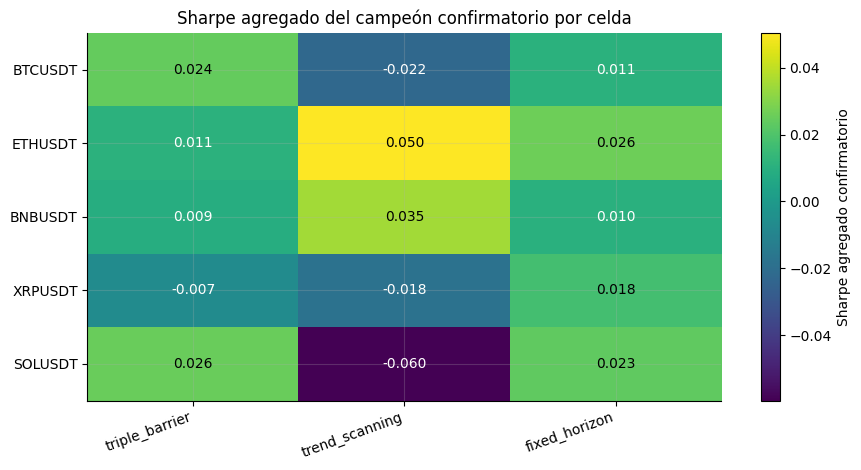

In [8]:
heatmap = executive_summary.pivot(
    index="symbol", columns="method", values="confirmatory_strategy_sharpe"
).reindex(index=EXPECTED_SYMBOLS, columns=EXPECTED_METHODS)
heatmap_values = heatmap.values.astype(float)
finite = heatmap_values[np.isfinite(heatmap_values)]
if finite.size:
    vmin_heatmap = float(min(0.0, finite.min()))
    vmax_heatmap = float(max(0.0, finite.max(), 1e-6))
else:
    vmin_heatmap, vmax_heatmap = 0.0, 0.05
cmap_heatmap = plt.get_cmap("viridis")
norm_heatmap = plt.Normalize(vmin=vmin_heatmap, vmax=vmax_heatmap)

fig, ax = plt.subplots(figsize=(9, 4.8))
im = ax.imshow(heatmap_values, aspect="auto", cmap=cmap_heatmap, norm=norm_heatmap)
ax.set_xticks(np.arange(len(heatmap.columns)), labels=heatmap.columns, rotation=20, ha="right")
ax.set_yticks(np.arange(len(heatmap.index)), labels=heatmap.index)
ax.set_title("Sharpe agregado del campeón confirmatorio por celda")
for i, symbol in enumerate(heatmap.index):
    for j, method in enumerate(heatmap.columns):
        value = heatmap.loc[symbol, method]
        if pd.isna(value):
            label = "NA"
        elif abs(float(value)) >= 0.001:
            label = f"{float(value):.3f}"
        else:
            label = f"{float(value):.1e}"
        r, g, b, _ = cmap_heatmap(norm_heatmap(float(value)) if pd.notna(value) else 0.0)
        text_color = "white" if (0.299 * r + 0.587 * g + 0.114 * b) < 0.55 else "black"
        ax.text(j, i, label, ha="center", va="center", color=text_color)
fig.colorbar(im, ax=ax, label="Sharpe agregado confirmatorio")
save_current_figure("01_confirmatory_sharpe_heatmap.png")
plt.show()

Figura guardada: reports/validation/experiments/baseline_shortlist_20260502T120458Z_evidence/figures/02_exploratory_vs_confirmatory_sharpe.png


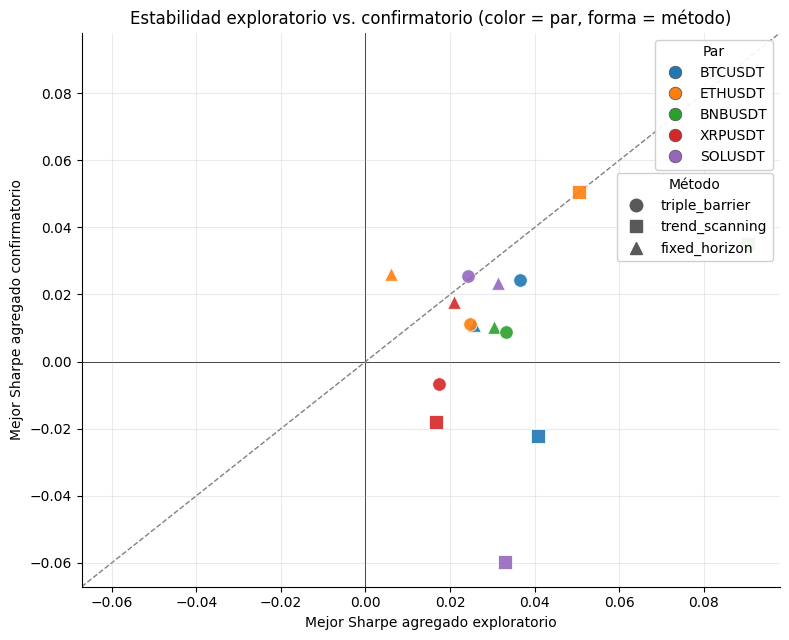

In [9]:
if not ranking.empty and "aggregate_strategy_sharpe" in ranking.columns:
    expl_best_sharpe = (
        ranking.assign(
            aggregate_strategy_sharpe=pd.to_numeric(
                ranking["aggregate_strategy_sharpe"], errors="coerce"
            )
        )
        .groupby(["symbol", "method"], as_index=False)["aggregate_strategy_sharpe"]
        .max()
        .rename(columns={"aggregate_strategy_sharpe": "exploratory_strategy_sharpe"})
    )
else:
    expl_best_sharpe = pd.DataFrame(columns=["symbol", "method", "exploratory_strategy_sharpe"])

scatter = (
    executive_summary.merge(expl_best_sharpe, on=["symbol", "method"], how="left")
    .dropna(subset=["exploratory_strategy_sharpe", "confirmatory_strategy_sharpe"])
    .copy()
)
symbol_colors = {
    symbol: plt.get_cmap("tab10")(i) for i, symbol in enumerate(EXPECTED_SYMBOLS)
}
method_markers = {"triple_barrier": "o", "trend_scanning": "s", "fixed_horizon": "^"}

fig, ax = plt.subplots(figsize=(8, 6.5))
for _, row in scatter.iterrows():
    ax.scatter(
        row["exploratory_strategy_sharpe"],
        row["confirmatory_strategy_sharpe"],
        c=[symbol_colors[row["symbol"]]],
        marker=method_markers.get(row["method"], "o"),
        s=95,
        alpha=0.9,
        edgecolors="white",
        linewidths=0.6,
        zorder=2,
    )
finite_vals = pd.concat([
    scatter["exploratory_strategy_sharpe"], scatter["confirmatory_strategy_sharpe"],
]).dropna()
if not finite_vals.empty:
    lo = float(min(0.0, finite_vals.min()))
    hi = float(max(0.0, finite_vals.max()))
    pad = max((hi - lo) * 0.05, 0.005)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad],
            linestyle="--", color="gray", linewidth=1, zorder=1)
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
ax.axhline(0, color="black", linewidth=0.6, zorder=0)
ax.axvline(0, color="black", linewidth=0.6, zorder=0)
ax.set_xlabel("Mejor Sharpe agregado exploratorio")
ax.set_ylabel("Mejor Sharpe agregado confirmatorio")
ax.set_title("Estabilidad exploratorio vs. confirmatorio (color = par, forma = método)")

symbol_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=symbol_colors[symbol],
        markeredgecolor="0.35",
        markeredgewidth=0.6,
        markersize=9,
        label=symbol,
    )
    for symbol in EXPECTED_SYMBOLS
    if symbol in scatter["symbol"].values
]
method_handles = [
    Line2D(
        [0],
        [0],
        marker=method_markers[method],
        color="0.35",
        markerfacecolor="0.35",
        linestyle="None",
        markersize=9,
        label=method,
    )
    for method in EXPECTED_METHODS
    if method in scatter["method"].values
]
legend_pairs = ax.legend(handles=symbol_handles, title="Par", loc="upper right", framealpha=0.92)
ax.add_artist(legend_pairs)
ax.legend(
    handles=method_handles,
    title="Método",
    loc="upper right",
    bbox_to_anchor=(1.0, 0.76),
    framealpha=0.92,
)
save_current_figure("02_exploratory_vs_confirmatory_sharpe.png")
plt.show()

Figura guardada: reports/validation/experiments/baseline_shortlist_20260502T120458Z_evidence/figures/03_confirmatory_winning_families.png


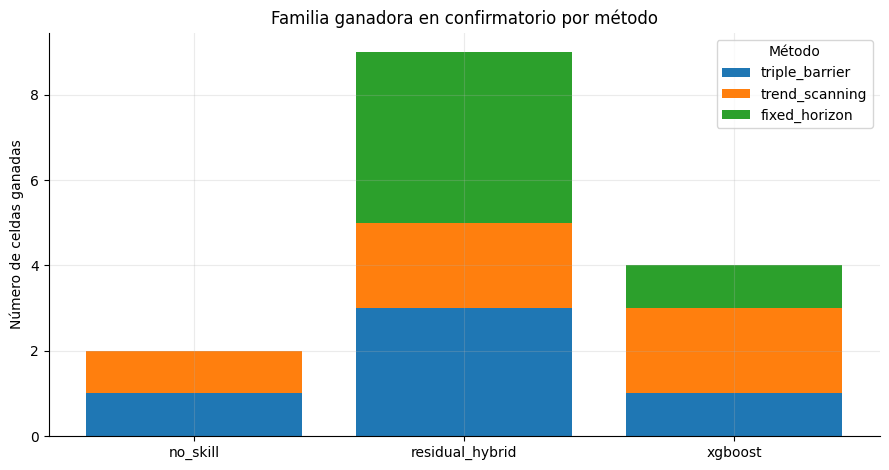

In [10]:
family_counts = (
    best_confirmatory.groupby(["family", "method"], dropna=False)
    .size()
    .rename("n_wins")
    .reset_index()
    .sort_values(["n_wins", "family"], ascending=[False, True])
)

pivot_family = family_counts.pivot(index="family", columns="method", values="n_wins").fillna(0).reindex(columns=EXPECTED_METHODS, fill_value=0)
fig, ax = plt.subplots(figsize=(9, 4.8))
bottom = np.zeros(len(pivot_family.index))
for method in EXPECTED_METHODS:
    values = pivot_family[method].values
    ax.bar(pivot_family.index, values, bottom=bottom, label=method)
    bottom += values
ax.set_ylabel("Número de celdas ganadas")
ax.set_title("Familia ganadora en confirmatorio por método")
ax.legend(title="Método")
save_current_figure("03_confirmatory_winning_families.png")
plt.show()

Figura guardada: reports/validation/experiments/baseline_shortlist_20260502T120458Z_evidence/figures/04_non_trivial_winning_families.png


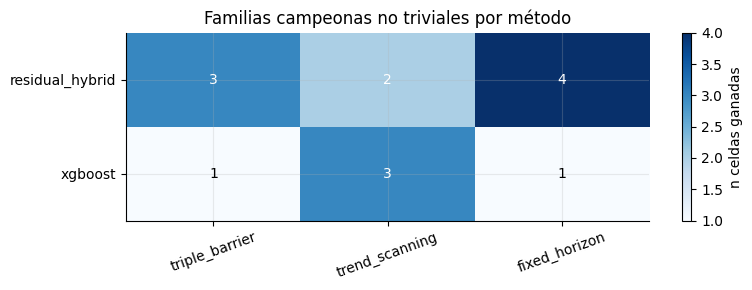

In [11]:
ANCHOR_FAMILY = "no_skill"

if global_confirmatory_ranking.empty:
    print("[aviso] No hay ranking confirmatorio disponible para la figura de familias no triviales.")
else:
    rank_view = global_confirmatory_ranking.copy()
    score_col = "aggregate_strategy_sharpe" if "aggregate_strategy_sharpe" in rank_view.columns else "study_close_dsr"
    rank_view[score_col] = pd.to_numeric(rank_view[score_col], errors="coerce")
    rank_view = rank_view.sort_values(["symbol", "method", score_col], ascending=[True, True, False])
    non_trivial = (
        rank_view[rank_view["family"].astype(str) != ANCHOR_FAMILY]
        .drop_duplicates(subset=["symbol", "method"], keep="first")
        .reset_index(drop=True)
    )
    pivot = (
        non_trivial.groupby(["family", "method"], dropna=False)
        .size()
        .rename("n_wins")
        .reset_index()
        .pivot(index="family", columns="method", values="n_wins")
        .fillna(0)
        .reindex(columns=list(EXPECTED_METHODS), fill_value=0)
        .astype(int)
    )
    fig, ax = plt.subplots(figsize=(8, max(3, 0.5 * len(pivot) + 1.5)))
    im = ax.imshow(pivot.values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(pivot.shape[1]), pivot.columns.tolist(), rotation=20)
    ax.set_yticks(range(pivot.shape[0]), pivot.index.tolist())
    vmax = max(int(pivot.values.max()), 1)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = int(pivot.values[i, j])
            ax.text(j, i, val, ha="center", va="center",
                    color="white" if val >= vmax / 2 else "black")
    ax.set_title("Familias campeonas no triviales por método")
    fig.colorbar(im, ax=ax, label="n celdas ganadas")
    fig.tight_layout()
    save_current_figure("04_non_trivial_winning_families.png")
    plt.show()


Figura guardada: reports/validation/experiments/baseline_shortlist_20260502T120458Z_evidence/figures/05_sharpe_dispersion_boxplots.png


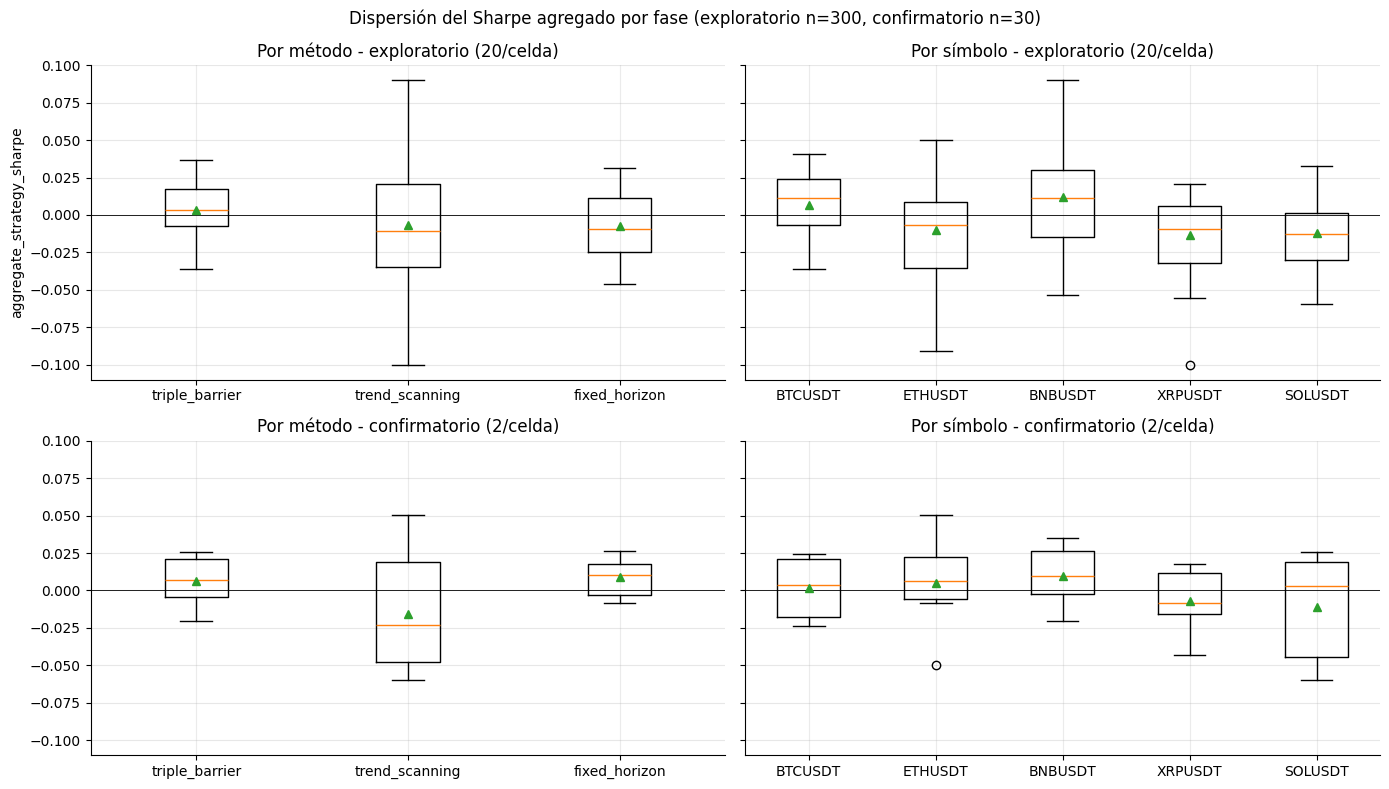

In [12]:
if ranking.empty and confirmatory.empty:
    print("[aviso] No hay trials con Sharpe para boxplots.")
else:
    box_parts: list[pd.DataFrame] = []
    if not ranking.empty and "aggregate_strategy_sharpe" in ranking.columns:
        expl = ranking[["symbol", "method", "aggregate_strategy_sharpe"]].copy()
        expl["phase"] = "exploratory"
        box_parts.append(expl)
    if not confirmatory.empty and "aggregate_strategy_sharpe" in confirmatory.columns:
        conf = confirmatory[["symbol", "method", "aggregate_strategy_sharpe"]].copy()
        conf["phase"] = "confirmatory"
        box_parts.append(conf)

    if not box_parts:
        print("[aviso] No hay columna aggregate_strategy_sharpe disponible para boxplots.")
    else:
        box_frame = pd.concat(box_parts, ignore_index=True)
        box_frame["aggregate_strategy_sharpe"] = pd.to_numeric(
            box_frame["aggregate_strategy_sharpe"], errors="coerce"
        )
        box_frame = box_frame.dropna(subset=["aggregate_strategy_sharpe"])

        phase_order = ["exploratory", "confirmatory"]
        phase_titles = {
            "exploratory": "exploratorio (20/celda)",
            "confirmatory": "confirmatorio (2/celda)",
        }
        methods_order = list(EXPECTED_METHODS)
        symbols_order = list(EXPECTED_SYMBOLS)

        fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)

        for row_idx, phase in enumerate(phase_order):
            sub = box_frame[box_frame["phase"] == phase]
            if sub.empty:
                for col_idx in (0, 1):
                    axes[row_idx, col_idx].text(
                        0.5,
                        0.5,
                        f"Sin datos ({phase_titles[phase]})",
                        ha="center",
                        va="center",
                        transform=axes[row_idx, col_idx].transAxes,
                    )
                    axes[row_idx, col_idx].set_axis_off()
                continue

            method_data = [
                sub[sub["method"] == m]["aggregate_strategy_sharpe"].values
                for m in methods_order
            ]
            axes[row_idx, 0].boxplot(method_data, tick_labels=methods_order, showmeans=True)
            axes[row_idx, 0].set_title(f"Por método - {phase_titles[phase]}")
            axes[row_idx, 0].axhline(0, color="black", linewidth=0.6)
            axes[row_idx, 0].grid(True, axis="y", alpha=0.3)
            if row_idx == 0:
                axes[row_idx, 0].set_ylabel("aggregate_strategy_sharpe")

            symbol_data = [
                sub[sub["symbol"] == s]["aggregate_strategy_sharpe"].values
                for s in symbols_order
            ]
            axes[row_idx, 1].boxplot(symbol_data, tick_labels=symbols_order, showmeans=True)
            axes[row_idx, 1].set_title(f"Por símbolo - {phase_titles[phase]}")
            axes[row_idx, 1].axhline(0, color="black", linewidth=0.6)
            axes[row_idx, 1].grid(True, axis="y", alpha=0.3)

        n_expl = int((box_frame["phase"] == "exploratory").sum())
        n_conf = int((box_frame["phase"] == "confirmatory").sum())
        fig.suptitle(
            "Dispersión del Sharpe agregado por fase "
            f"(exploratorio n={n_expl}, confirmatorio n={n_conf})"
        )
        fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.94))
        save_current_figure("05_sharpe_dispersion_boxplots.png")
        plt.show()


## 3.6 Distribución del Sharpe agregado del campeón no trivial

Histograma del **Sharpe agregado** *out-of-sample* del campeón no trivial por celda (excluye `no_skill`). Complementa el *heatmap* de la sección 3.1 (vista celda a celda) y los *boxplots* de la sección 3.5 (dispersión por método y símbolo) ofreciendo la distribución agregada para apreciar el rango de magnitudes.

Figura guardada: reports/validation/experiments/baseline_shortlist_20260502T120458Z_evidence/figures/06_non_trivial_champion_sharpe_distribution.png


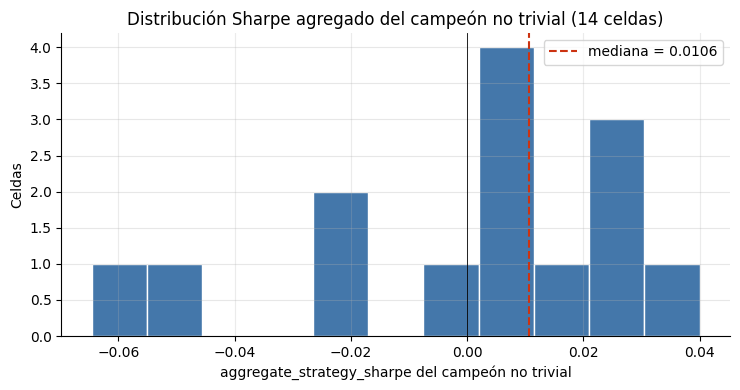

In [13]:
if global_confirmatory_ranking.empty or "non_trivial" not in dir():
    print("[aviso] No hay ranking confirmatorio disponible para el histograma de campeones no triviales.")
else:
    score_col = "aggregate_strategy_sharpe"
    if score_col not in non_trivial.columns:
        print(f"[aviso] La columna {score_col} no está disponible en non_trivial.")
    else:
        sharpes_campeon = pd.to_numeric(non_trivial[score_col], errors="coerce").dropna()
        if sharpes_campeon.empty:
            print("[aviso] No hay Sharpes agregados válidos para el histograma.")
        else:
            mediana_campeon = float(sharpes_campeon.median())
            x_min = float(min(0.0, sharpes_campeon.min()))
            x_max = float(max(0.0, sharpes_campeon.max()))
            pad = max((x_max - x_min) * 0.05, 0.005)
            bins = np.linspace(x_min - pad, x_max + pad, 12)

            fig, ax = plt.subplots(figsize=(7.5, 4))
            ax.hist(sharpes_campeon.values, bins=bins, color="#4477AA", edgecolor="white")
            ax.axvline(0, color="black", linewidth=0.6)
            ax.axvline(
                mediana_campeon,
                color="#CC3311",
                linestyle="--",
                label=f"mediana = {mediana_campeon:.4f}",
            )
            ax.set_title(
                f"Distribución Sharpe agregado del campeón no trivial ({len(sharpes_campeon)} celdas)"
            )
            ax.set_xlabel("aggregate_strategy_sharpe del campeón no trivial")
            ax.set_ylabel("Celdas")
            ax.legend(loc="upper right")
            ax.grid(axis="y", alpha=0.3)
            save_current_figure("06_non_trivial_champion_sharpe_distribution.png")
            plt.show()


## Cierre

La evidencia local de la campaña Exp1 queda organizada en tres niveles complementarios:

1. **Integridad operativa**: 15 summaries cargados en el comienzo (contadores exploratorio/confirmatorio visibles al cargar); 22 trials por celda (20 exploratorios + 2 confirmatorios).
2. **Lectura analítica**: tabla ejecutiva slim por celda (Sharpe primario), ranking confirmatorio, estabilidad por familia y promoción diversificada exportados como CSV/HTML.
3. **Evidencia gráfica**: *heatmap* del Sharpe agregado del campeón confirmatorio, *scatter* Sharpe exploratorio vs confirmatorio, conteos de familia ganadora con y sin `no_skill`, *boxplots* del Sharpe por método/símbolo **en ambas fases**, y distribución agregada del Sharpe del campeón no trivial.

El **DSR diagnóstico Exp1** (`diagnostic_study_close_dsr`, deflactado con N=22 por celda) se conserva como columna de auditoría en los CSV exportados. La deflación coherente del carril completo (Exp1 + Exp2 + carril 2.5) no se evalúa aquí: se reporta en `05_resumen_greedy_contextual.ipynb` (sección 7) y `06_resumen_carril_riesgo_greedy_contextual.ipynb` (sección 8), recalculada desde los retornos OOS reales con el N total acumulado por celda `(simbolo, metodo)` y persistida en `reports/validation/dsr_exact/dsr_exact_post_experiment_supervised.csv`.

### Productos exportados

Raíz: `reports/validation/experiments/baseline_shortlist_20260502T120458Z_evidence/`

**Tablas** (`tables/`):

- `baseline_shortlist_executive_summary.csv` / `.html`
- `baseline_shortlist_executive_summary_audit.csv` / `.html`
- `baseline_shortlist_confirmatory_ranking.csv` / `.html`
- `baseline_shortlist_exploratory_ranking.csv` / `.html`
- `baseline_shortlist_family_stability.csv`
- `baseline_shortlist_diversified_promotion.csv`

**Figuras** (`figures/`):

- `01_confirmatory_sharpe_heatmap.png`
- `02_exploratory_vs_confirmatory_sharpe.png`
- `03_confirmatory_winning_families.png`
- `04_non_trivial_winning_families.png`
- `05_sharpe_dispersion_boxplots.png`
- `06_non_trivial_champion_sharpe_distribution.png`

**Entrada externa (solo lectura):** `baseline_shortlist_global_dsr_manifest.json`, `tables/baseline_shortlist_global_dsr_rows.csv` y `tables/baseline_shortlist_global_dsr_studies.csv` (generados por `scripts/recompute_global_dsr_baseline_shortlist.py`).

### Notebooks relacionados

- `05_modelado_predictivo/02_evidencia_robustez_fold_shortlist_baseline.ipynb`: complemento fold-level (mismo manifest `_evidence/`).
- `scripts/check_study_admission.py`: admisión contractual (CLI) y presencia del ledger `trial_registry` en el bundle de cierre.
- `05_modelado_predictivo/05_resumen_greedy_contextual.ipynb` y `06_resumen_carril_riesgo_greedy_contextual.ipynb`: DSR deflactado de campaña (secciones 7 y 8).